# Notebook 00 - Basic 3D Kinematics

## Purpose

This notebook develops and validates the **smallest functioning three-dimensional motion model** for HydroLab-3D.

The objective is deliberately simple: represent one virtual underwater vehicle as a point in three-dimensional space, assign it a translational velocity, advance its position through time, generate a trajectory, and verify that the numerical result agrees with the corresponding analytical solution.

At this stage, the vehicle has **no orientation, forces, mass, drag, buoyancy, thrusters, currents, sensors, or control system**.

The notebook is concerned only with one fundamental question:

> **Can HydroLab-3D advance a vehicle through 3D space correctly, deterministically, and reproducibly?**

This establishes the mathematical foundation upon which every later vehicle model will be built.

---

## Why This Matters

Every future HydroLab-3D vehicle model ultimately requires reliable state propagation.

Later notebooks will introduce:

- orientation and reference frames;
- acceleration and force-based dynamics;
- hydrodynamic drag;
- gravity and buoyancy;
- thruster forces;
- ocean currents;
- full 6-DOF marine dynamics;
- sensors;
- closed-loop control;
- and eventually simulator-kernel integration.

Before adding those layers, the most elementary state update must be trustworthy.

The development sequence therefore begins with:

```text
Position
    +
Velocity
    +
Time Step
    ↓
Updated Position
    ↓
Trajectory
    ↓
Analytical Validation
```

The philosophy is intentionally conservative:

> **Validate the simplest mathematical layer before allowing additional physics to depend on it.**

---

## What We Will Implement

This notebook will implement:

- a three-dimensional world-frame position vector;
- a three-dimensional world-frame velocity vector;
- deterministic timestep-based position integration;
- simple piecewise-constant velocity commands;
- simulation-time generation;
- trajectory recording;
- analytical constant-velocity reference solutions;
- numerical-versus-analytical validation;
- three-dimensional trajectory visualization;
- position-versus-time visualization;
- persistent CSV output containing the simulated trajectory.

The initial model represents the vehicle as a **kinematic point mass**.

Velocity is commanded directly.

There is no acceleration model and no force model in this notebook.

---

## Mathematical Model

Let the vehicle position in the world reference frame be

$$
\mathbf{p}(t)
=
\begin{bmatrix}
x(t) \\
y(t) \\
z(t)
\end{bmatrix}
$$

and let its translational velocity in the same frame be

$$
\mathbf{v}(t)
=
\begin{bmatrix}
v_x(t) \\
v_y(t) \\
v_z(t)
\end{bmatrix}.
$$

The basic three-dimensional kinematic model is

$$
\dot{\mathbf{p}}(t)=\mathbf{v}(t).
$$

Equivalently,

$$
\dot{x}=v_x,
$$

$$
\dot{y}=v_y,
$$

$$
\dot{z}=v_z.
$$

For constant velocity,

$$
\mathbf{v}(t)=\mathbf{v}_0,
$$

the analytical solution is

$$
\mathbf{p}(t)
=
\mathbf{p}_0+\mathbf{v}_0t.
$$

Therefore,

$$
x(t)=x_0+v_xt,
$$

$$
y(t)=y_0+v_yt,
$$

$$
z(t)=z_0+v_zt.
$$

For a discrete simulation with timestep $\Delta t$, position will be propagated using

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t.
$$

Component-wise,

$$
x_{k+1}=x_k+v_{x,k}\Delta t,
$$

$$
y_{k+1}=y_k+v_{y,k}\Delta t,
$$

$$
z_{k+1}=z_k+v_{z,k}\Delta t.
$$

When $\mathbf{v}_k$ remains constant throughout a timestep, this update is the exact discrete propagation of the constant-velocity kinematic model over that interval.

This distinction is important: the notebook is not yet approximating acceleration-driven dynamics. It is integrating a velocity that is assumed constant during each simulation step.

---

## State Representation

The minimum vehicle state required by this notebook is

$$
\mathbf{s}
=
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix}.
$$

The commanded translational velocity is

$$
\mathbf{u}
=
\begin{bmatrix}
v_x \\
v_y \\
v_z
\end{bmatrix}.
$$

At this stage,

$$
\mathbf{u}=\mathbf{v}.
$$

In later HydroLab-3D models, commands will no longer manipulate position propagation this directly. Commands will eventually pass through actuator and dynamic models before affecting vehicle motion.

---

## Coordinate Convention

This notebook operates entirely in the **world reference frame**.

The coordinates are:

- $x$ — first horizontal world axis;
- $y$ — second horizontal world axis;
- $z$ — vertical world axis.

HydroLab-3D uses the convention that the water surface is located at

$$
z=0,
$$

with underwater positions generally occupying negative $z$ values.

Orientation is intentionally absent from this notebook.

Therefore, a velocity such as

$$
\mathbf{v}
=
\begin{bmatrix}
1 \\
0 \\
0
\end{bmatrix}
$$

means motion directly along the positive world $x$ direction.

Body-relative motion will be introduced separately in **Notebook 01 - Orientation and Reference Frames**.

---

## Simulation Concept

The numerical loop developed here will follow the structure

```text
Initial Position
      ↓
Velocity Command
      ↓
Current State
      ↓
Kinematic Update
      ↓
New 3D Position
      ↓
Record State
      ↓
Advance Time
      ↓
Repeat
```

The resulting sequence of positions forms the vehicle trajectory.

For piecewise-constant commands, each individual simulation interval follows the same mathematical update while the commanded velocity may change between intervals.

---

## Expected Result

If the implementation is correct:

1. a stationary vehicle should remain at its initial position;
2. constant velocity along one axis should produce a straight-line trajectory along that axis;
3. simultaneous non-zero velocity components should produce the corresponding straight-line trajectory in 3D;
4. reversing a velocity component should reverse motion along that world axis;
5. the discrete trajectory should agree with the analytical constant-velocity solution;
6. repeated runs using identical initial conditions and commands should produce identical results;
7. the recorded simulation timestamps and vehicle states should remain finite and internally consistent.

For a constant velocity command, the simulated trajectory should satisfy

$$
\mathbf{p}_k
\approx
\mathbf{p}_0+\mathbf{v}t_k,
$$

with differences limited only to normal floating-point numerical precision.

---

## Validation Criteria

This notebook will be considered successful only if all of the following conditions are satisfied.

### 1. Analytical Agreement

For constant-velocity test cases, the numerical solution must agree with

$$
\mathbf{p}(t)=\mathbf{p}_0+\mathbf{v}t
$$

to within a numerical tolerance of

$$
10^{-10}
$$

for the tested position coordinates.

### 2. Stationary-State Test

For

$$
\mathbf{v}
=
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix},
$$

the position must remain unchanged for the full simulation.

### 3. Axis-Motion Tests

Independent commands along $x$, $y$, and $z$ must affect only their corresponding coordinates.

### 4. Three-Dimensional Motion Test

A velocity vector containing simultaneous non-zero $x$, $y$, and $z$ components must produce the analytically expected 3D trajectory.

### 5. Numerical Integrity

The simulation must generate no:

- `NaN` values;
- infinite values;
- malformed state vectors;
- inconsistent timestamps.

### 6. Reproducibility

Running the same deterministic scenario twice must produce the same numerical trajectory.

### 7. Output Integrity

The expected plots and trajectory dataset must be generated successfully and stored in the designated notebook-results directory.

---

## Relationship to HydroLab-3D

This notebook establishes the **Level 0 kinematic vehicle model**.

Its validated state-propagation logic will provide the first mathematical building block of HydroLab-3D:

```text
3D Position Integration
        ↓
Orientation and Reference Frames
        ↓
Basic Dynamics
        ↓
Hydrodynamics
        ↓
6-DOF UUV Model
        ↓
Simulator Kernel
```

The reusable kinematic implementation developed here may later be promoted into:

```text
src/hydrolab3d/dynamics/kinematics.py
```

after its behavior has been validated.

The notebook should then eventually import the production implementation rather than maintaining a duplicate simulator model.

---

## Scope Boundary

This notebook intentionally does **not** model:

- roll;
- pitch;
- yaw;
- body-frame velocity;
- coordinate-frame transformations;
- acceleration;
- vehicle mass;
- forces;
- torques;
- hydrodynamic drag;
- gravity;
- buoyancy;
- thrusters;
- ocean currents;
- terrain interaction;
- sensors;
- control algorithms;
- ROS 2;
- machine learning;
- rendering.

Those capabilities belong to later stages of the HydroLab-3D notebook pipeline.

The goal here is narrower:

$$
\boxed{
\text{Make basic 3D translational kinematics trustworthy first.}
}
$$

---

## Expected Outputs

The notebook is expected to generate the following persistent artifacts:

```text
results/notebooks/00_basic_3d_kinematics/
│
├── plots/
│   ├── trajectory_3d.png
│   └── position_vs_time.png
│
└── data/
    └── trajectory.csv
```

### `trajectory_3d.png`

A three-dimensional visualization of the simulated vehicle trajectory.

### `position_vs_time.png`

A time-history visualization of the vehicle coordinates $x(t)$, $y(t)$, and $z(t)$.

### `trajectory.csv`

A numerical record of the simulated trajectory suitable for later inspection, validation, reproduction, or reuse.

At minimum, the dataset should preserve:

```text
time
x
y
z
vx
vy
vz
```

Additional validation quantities may be included if they prove useful during development.

---

## Output Directory

All persistent artifacts generated by this notebook will be stored under:

```text
results/notebooks/00_basic_3d_kinematics/
```

Subdirectories will be created only when required:

```text
plots/
data/
```

No unnecessary directories will be introduced.

---

## Engineering Handoff Target

The final result of this notebook should provide a validated answer to:

> **Given a known 3D position, world-frame velocity, and timestep, can HydroLab-3D propagate the vehicle state correctly?**

Once that answer has been established numerically and analytically, the next notebook can safely introduce vehicle orientation and reference-frame transformations.

The direct handoff is therefore:

```text
00_basic_3d_kinematics.ipynb
        │
        │ validated 3D position integration
        ▼
01_orientation.ipynb
        │
        └── body-frame velocity
            → rotation transformation
            → world-frame motion
```

Notebook 00 establishes **where the vehicle moves**.

Notebook 01 will establish **how its orientation determines that motion**.

---

## Step 1 - Notebook Setup and Output Paths

Before implementing any kinematics, we initialize the numerical and plotting tools used by this notebook and define the persistent output directories specified by the HydroLab-3D repository structure.

This step creates only the directories required by Notebook 00:

    results/notebooks/00_basic_3d_kinematics/
    ├── plots/
    └── data/

No simulation mathematics is executed yet.

Keeping output-path creation explicit at the beginning ensures that every later plot and dataset produced by this notebook has a deterministic location and can be referenced by subsequent notebooks.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Notebook output directories
# ---------------------------------------------------------------------

OUTPUT_DIR = Path("../results/notebooks/00_basic_3d_kinematics")
PLOTS_DIR = OUTPUT_DIR / "plots"
DATA_DIR = OUTPUT_DIR / "data"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------------
# Verify notebook environment
# ---------------------------------------------------------------------

print("Notebook 00 initialized successfully.")
print(f"NumPy version: {np.__version__}")
print()
print("Output directories:")
print(f"  Root : {OUTPUT_DIR.resolve()}")
print(f"  Plots: {PLOTS_DIR.resolve()}")
print(f"  Data : {DATA_DIR.resolve()}")

Notebook 00 initialized successfully.
NumPy version: 2.5.2

Output directories:
  Root : /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics
  Plots: /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/plots
  Data : /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/data


## Step 2 - Define the Initial 3D Kinematic State

We now define the minimum state required for the first HydroLab-3D vehicle model.

The vehicle is represented only by its position in the world frame,

$$
\mathbf{p}
=
\begin{bmatrix}
x \\
y \\
z
\end{bmatrix},
$$

and by its translational velocity,

$$
\mathbf{v}
=
\begin{bmatrix}
v_x \\
v_y \\
v_z
\end{bmatrix}.
$$

The continuous-time kinematic relationship is

$$
\dot{\mathbf{p}}=\mathbf{v}.
$$

For a simulation timestep $\Delta t$, assuming velocity remains constant over one timestep, the exact discrete update is

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k \Delta t.
$$

We begin with a simple deterministic test state:

- initial position: $(0,\ 0,\ -10)$ m;
- velocity: $(1,\ 0.5,\ -0.25)$ m/s;
- timestep: $\Delta t=0.1$ s.

The negative initial $z$ coordinate places the vehicle below the HydroLab-3D water surface convention $z=0$.

No integration is performed in this step. We only define and inspect the state that later steps will propagate.

In [2]:
# ---------------------------------------------------------------------
# Initial 3D kinematic state
# ---------------------------------------------------------------------

position_0 = np.array([0.0, 0.0, -10.0], dtype=float)
velocity = np.array([1.0, 0.5, -0.25], dtype=float)

dt = 0.1  # seconds


# ---------------------------------------------------------------------
# Basic state validation
# ---------------------------------------------------------------------

assert position_0.shape == (3,)
assert velocity.shape == (3,)
assert np.all(np.isfinite(position_0))
assert np.all(np.isfinite(velocity))
assert np.isfinite(dt)
assert dt > 0.0


# ---------------------------------------------------------------------
# Inspect the defined state
# ---------------------------------------------------------------------

print("Initial kinematic state defined successfully.")
print(f"Initial position [m] : {position_0}")
print(f"Velocity [m/s]       : {velocity}")
print(f"Timestep [s]         : {dt}")

Initial kinematic state defined successfully.
Initial position [m] : [  0.   0. -10.]
Velocity [m/s]       : [ 1.    0.5  -0.25]
Timestep [s]         : 0.1


## Step 3 - Implement One-Step Position Integration

We now implement the smallest reusable numerical operation in Notebook 00: advancing the vehicle position by one simulation timestep.

The kinematic model is

$$
\dot{\mathbf{p}}=\mathbf{v}.
$$

Assuming velocity remains constant during one timestep $\Delta t$, integration over that interval gives

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t.
$$

For the state defined in Step 2,

$$
\mathbf{p}_0=
\begin{bmatrix}
0 \\
0 \\
-10
\end{bmatrix},
\qquad
\mathbf{v}=
\begin{bmatrix}
1 \\
0.5 \\
-0.25
\end{bmatrix},
\qquad
\Delta t=0.1,
$$

the expected position after one timestep is

$$
\mathbf{p}_1=
\begin{bmatrix}
0.1 \\
0.05 \\
-10.025
\end{bmatrix}.
$$

This step implements the update as a small function and verifies one timestep against that analytically calculated result.

In [3]:
def integrate_position(position, velocity, dt):
    """
    Advance a 3D position by one constant-velocity timestep.

    Parameters
    ----------
    position : np.ndarray
        Current world-frame position [x, y, z] in meters.
    velocity : np.ndarray
        Current world-frame velocity [vx, vy, vz] in meters/second.
    dt : float
        Simulation timestep in seconds.

    Returns
    -------
    np.ndarray
        Updated world-frame position after one timestep.
    """
    position = np.asarray(position, dtype=float)
    velocity = np.asarray(velocity, dtype=float)

    if position.shape != (3,):
        raise ValueError("position must have shape (3,)")

    if velocity.shape != (3,):
        raise ValueError("velocity must have shape (3,)")

    if not np.all(np.isfinite(position)):
        raise ValueError("position must contain only finite values")

    if not np.all(np.isfinite(velocity)):
        raise ValueError("velocity must contain only finite values")

    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("dt must be a positive finite scalar")

    return position + velocity * dt


# ---------------------------------------------------------------------
# One-step analytical validation
# ---------------------------------------------------------------------

position_1 = integrate_position(position_0, velocity, dt)

expected_position_1 = np.array([
    0.1,
    0.05,
    -10.025
])

error = position_1 - expected_position_1

assert np.allclose(position_1, expected_position_1, atol=1e-12, rtol=0.0)


print("One-step position integration validated successfully.")
print(f"Computed position [m] : {position_1}")
print(f"Expected position [m] : {expected_position_1}")
print(f"Absolute error [m]    : {np.abs(error)}")

One-step position integration validated successfully.
Computed position [m] : [  0.1     0.05  -10.025]
Expected position [m] : [  0.1     0.05  -10.025]
Absolute error [m]    : [0. 0. 0.]


## Step 4 - Validate the Stationary Vehicle Case

Before testing motion, we verify the simplest invariant of the kinematic model:

> A vehicle with zero velocity must remain exactly at its initial position.

For

$$
\mathbf{v}
=
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix},
$$

the discrete update becomes

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k.
$$

Therefore, regardless of the timestep,

$$
\mathbf{p}(t)=\mathbf{p}_0.
$$

We propagate the vehicle over multiple simulation steps and confirm that:

- the position never changes;
- all states remain finite;
- the final position is identical to the initial position.

This test checks that the integration logic does not introduce artificial drift when no motion is commanded.

In [4]:
# ---------------------------------------------------------------------
# Stationary-vehicle validation
# ---------------------------------------------------------------------

stationary_position_0 = np.array([4.0, -3.0, -12.0], dtype=float)
stationary_velocity = np.zeros(3, dtype=float)

stationary_dt = 0.1
stationary_steps = 100

stationary_position = stationary_position_0.copy()
stationary_history = [stationary_position.copy()]

for _ in range(stationary_steps):
    stationary_position = integrate_position(
        stationary_position,
        stationary_velocity,
        stationary_dt
    )
    stationary_history.append(stationary_position.copy())

stationary_history = np.asarray(stationary_history)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

expected_stationary_history = np.repeat(
    stationary_position_0[None, :],
    stationary_steps + 1,
    axis=0
)

assert stationary_history.shape == (stationary_steps + 1, 3)
assert np.all(np.isfinite(stationary_history))
assert np.array_equal(stationary_history, expected_stationary_history)
assert np.array_equal(stationary_position, stationary_position_0)


print("Stationary-vehicle validation passed.")
print(f"Initial position [m] : {stationary_position_0}")
print(f"Final position [m]   : {stationary_position}")
print(f"Simulation steps     : {stationary_steps}")
print(f"Total simulated time : {stationary_steps * stationary_dt:.1f} s")
print(f"Maximum drift [m]    : {np.max(np.abs(stationary_history - stationary_position_0))}")

Stationary-vehicle validation passed.
Initial position [m] : [  4.  -3. -12.]
Final position [m]   : [  4.  -3. -12.]
Simulation steps     : 100
Total simulated time : 10.0 s
Maximum drift [m]    : 0.0


## Step 5 - Validate Pure X-Axis Motion

We now verify that motion along a single world axis affects only that axis.

For a velocity

$$
\mathbf{v}
=
\begin{bmatrix}
v_x \\
0 \\
0
\end{bmatrix},
$$

the kinematic equations reduce to

$$
\dot{x}=v_x,
$$

$$
\dot{y}=0,
$$

$$
\dot{z}=0.
$$

For constant $v_x$, the analytical solution is

$$
x(t)=x_0+v_xt,
$$

while

$$
y(t)=y_0
$$

and

$$
z(t)=z_0.
$$

This test propagates a vehicle with a constant positive $x$-velocity for multiple timesteps and compares the entire numerical trajectory against the analytical solution.

Successful validation requires:

- the numerical $x$ position to match the analytical trajectory;
- the $y$ coordinate to remain unchanged;
- the $z$ coordinate to remain unchanged;
- the maximum trajectory error to remain below the notebook tolerance.

In [5]:
# ---------------------------------------------------------------------
# Pure X-axis motion validation
# ---------------------------------------------------------------------

x_position_0 = np.array([2.0, -4.0, -15.0], dtype=float)
x_velocity = np.array([1.5, 0.0, 0.0], dtype=float)

x_dt = 0.1
x_steps = 100

x_position = x_position_0.copy()
x_history = [x_position.copy()]

for _ in range(x_steps):
    x_position = integrate_position(
        x_position,
        x_velocity,
        x_dt
    )
    x_history.append(x_position.copy())

x_history = np.asarray(x_history)

# Time includes the initial state at t = 0.
x_time = np.arange(x_steps + 1, dtype=float) * x_dt


# ---------------------------------------------------------------------
# Analytical reference
# ---------------------------------------------------------------------

x_expected = (
    x_position_0[None, :]
    + x_time[:, None] * x_velocity[None, :]
)

x_error = x_history - x_expected
x_max_error = np.max(np.abs(x_error))


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert x_history.shape == (x_steps + 1, 3)
assert np.all(np.isfinite(x_history))

assert np.allclose(
    x_history,
    x_expected,
    atol=1e-10,
    rtol=0.0
)

assert np.allclose(
    x_history[:, 1],
    x_position_0[1],
    atol=1e-12,
    rtol=0.0
)

assert np.allclose(
    x_history[:, 2],
    x_position_0[2],
    atol=1e-12,
    rtol=0.0
)


print("Pure X-axis motion validation passed.")
print(f"Initial position [m] : {x_position_0}")
print(f"Velocity [m/s]       : {x_velocity}")
print(f"Final position [m]   : {x_history[-1]}")
print(f"Expected final [m]   : {x_expected[-1]}")
print(f"Total simulated time : {x_time[-1]:.1f} s")
print(f"Maximum error [m]    : {x_max_error:.3e}")

Pure X-axis motion validation passed.
Initial position [m] : [  2.  -4. -15.]
Velocity [m/s]       : [1.5 0.  0. ]
Final position [m]   : [ 17.  -4. -15.]
Expected final [m]   : [ 17.  -4. -15.]
Total simulated time : 10.0 s
Maximum error [m]    : 2.665e-14


## Step 6 - Validate Independent Y-Axis and Z-Axis Motion

The previous test verified motion along the world $x$ axis.

We now verify the remaining translational axes independently to ensure that each velocity component affects only its corresponding position coordinate.

For pure $y$-axis motion,

$$
\mathbf{v}
=
\begin{bmatrix}
0 \\
v_y \\
0
\end{bmatrix},
$$

the analytical solution is

$$
x(t)=x_0,
$$

$$
y(t)=y_0+v_yt,
$$

$$
z(t)=z_0.
$$

For pure $z$-axis motion,

$$
\mathbf{v}
=
\begin{bmatrix}
0 \\
0 \\
v_z
\end{bmatrix},
$$

the analytical solution is

$$
x(t)=x_0,
$$

$$
y(t)=y_0,
$$

$$
z(t)=z_0+v_zt.
$$

Because HydroLab-3D uses $z=0$ as the water surface, a negative $v_z$ command moves the vehicle toward more negative $z$, corresponding to deeper underwater motion under the convention used in this notebook.

Both trajectories will be propagated numerically and compared against their complete analytical references.

In [6]:
# ---------------------------------------------------------------------
# Pure Y-axis motion validation
# ---------------------------------------------------------------------

y_position_0 = np.array([-3.0, 2.0, -8.0], dtype=float)
y_velocity = np.array([0.0, -0.75, 0.0], dtype=float)

axis_dt = 0.1
axis_steps = 100

y_position = y_position_0.copy()
y_history = [y_position.copy()]

for _ in range(axis_steps):
    y_position = integrate_position(
        y_position,
        y_velocity,
        axis_dt
    )
    y_history.append(y_position.copy())

y_history = np.asarray(y_history)

axis_time = np.arange(axis_steps + 1, dtype=float) * axis_dt

y_expected = (
    y_position_0[None, :]
    + axis_time[:, None] * y_velocity[None, :]
)

y_max_error = np.max(np.abs(y_history - y_expected))


# ---------------------------------------------------------------------
# Pure Z-axis motion validation
# ---------------------------------------------------------------------

z_position_0 = np.array([5.0, -2.0, -6.0], dtype=float)
z_velocity = np.array([0.0, 0.0, -0.4], dtype=float)

z_position = z_position_0.copy()
z_history = [z_position.copy()]

for _ in range(axis_steps):
    z_position = integrate_position(
        z_position,
        z_velocity,
        axis_dt
    )
    z_history.append(z_position.copy())

z_history = np.asarray(z_history)

z_expected = (
    z_position_0[None, :]
    + axis_time[:, None] * z_velocity[None, :]
)

z_max_error = np.max(np.abs(z_history - z_expected))


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert y_history.shape == (axis_steps + 1, 3)
assert z_history.shape == (axis_steps + 1, 3)

assert np.all(np.isfinite(y_history))
assert np.all(np.isfinite(z_history))

assert np.allclose(
    y_history,
    y_expected,
    atol=1e-10,
    rtol=0.0
)

assert np.allclose(
    z_history,
    z_expected,
    atol=1e-10,
    rtol=0.0
)

# Uncommanded coordinates must remain unchanged.
assert np.allclose(y_history[:, 0], y_position_0[0], atol=1e-12, rtol=0.0)
assert np.allclose(y_history[:, 2], y_position_0[2], atol=1e-12, rtol=0.0)

assert np.allclose(z_history[:, 0], z_position_0[0], atol=1e-12, rtol=0.0)
assert np.allclose(z_history[:, 1], z_position_0[1], atol=1e-12, rtol=0.0)


print("Independent Y-axis and Z-axis validations passed.")
print()
print("Y-axis test:")
print(f"  Final position [m] : {y_history[-1]}")
print(f"  Expected final [m] : {y_expected[-1]}")
print(f"  Maximum error [m]  : {y_max_error:.3e}")
print()
print("Z-axis test:")
print(f"  Final position [m] : {z_history[-1]}")
print(f"  Expected final [m] : {z_expected[-1]}")
print(f"  Maximum error [m]  : {z_max_error:.3e}")

Independent Y-axis and Z-axis validations passed.

Y-axis test:
  Final position [m] : [-3.  -5.5 -8. ]
  Expected final [m] : [-3.  -5.5 -8. ]
  Maximum error [m]  : 6.217e-15

Z-axis test:
  Final position [m] : [  5.  -2. -10.]
  Expected final [m] : [  5.  -2. -10.]
  Maximum error [m]  : 4.086e-14


## Step 7 - Validate Simultaneous 3D Constant-Velocity Motion

Having validated the three world axes independently, we now test the actual three-dimensional case in which all velocity components are non-zero simultaneously.

For constant world-frame velocity

$$
\mathbf{v}
=
\begin{bmatrix}
v_x \\
v_y \\
v_z
\end{bmatrix},
$$

the kinematic model remains

$$
\dot{\mathbf{p}}=\mathbf{v}.
$$

The analytical solution is

$$
\mathbf{p}(t)
=
\mathbf{p}_0+\mathbf{v}t.
$$

Component-wise,

$$
x(t)=x_0+v_xt,
$$

$$
y(t)=y_0+v_yt,
$$

$$
z(t)=z_0+v_zt.
$$

This test is important because it verifies that the vector implementation correctly propagates coupled three-dimensional motion rather than merely passing separate single-axis cases.

We will simulate a constant 3D velocity for 20 seconds and compare every numerical state against the analytical trajectory.

The test passes only if the complete trajectory remains within the notebook tolerance of the analytical reference.

In [7]:
# ---------------------------------------------------------------------
# Simultaneous 3D constant-velocity validation
# ---------------------------------------------------------------------

motion_3d_position_0 = np.array([1.0, -2.0, -5.0], dtype=float)
motion_3d_velocity = np.array([1.2, -0.7, 0.3], dtype=float)

motion_3d_dt = 0.1
motion_3d_steps = 200

motion_3d_position = motion_3d_position_0.copy()
motion_3d_history = [motion_3d_position.copy()]

for _ in range(motion_3d_steps):
    motion_3d_position = integrate_position(
        motion_3d_position,
        motion_3d_velocity,
        motion_3d_dt
    )
    motion_3d_history.append(motion_3d_position.copy())

motion_3d_history = np.asarray(motion_3d_history)

motion_3d_time = (
    np.arange(motion_3d_steps + 1, dtype=float)
    * motion_3d_dt
)


# ---------------------------------------------------------------------
# Analytical reference
# ---------------------------------------------------------------------

motion_3d_expected = (
    motion_3d_position_0[None, :]
    + motion_3d_time[:, None] * motion_3d_velocity[None, :]
)

motion_3d_error = motion_3d_history - motion_3d_expected

motion_3d_max_error = np.max(
    np.abs(motion_3d_error)
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert motion_3d_history.shape == (motion_3d_steps + 1, 3)
assert np.all(np.isfinite(motion_3d_history))

assert np.allclose(
    motion_3d_history,
    motion_3d_expected,
    atol=1e-10,
    rtol=0.0
)

assert motion_3d_max_error < 1e-10


print("Simultaneous 3D motion validation passed.")
print(f"Initial position [m] : {motion_3d_position_0}")
print(f"Velocity [m/s]       : {motion_3d_velocity}")
print(f"Final position [m]   : {motion_3d_history[-1]}")
print(f"Expected final [m]   : {motion_3d_expected[-1]}")
print(f"Total simulated time : {motion_3d_time[-1]:.1f} s")
print(f"Maximum error [m]    : {motion_3d_max_error:.3e}")

Simultaneous 3D motion validation passed.
Initial position [m] : [ 1. -2. -5.]
Velocity [m/s]       : [ 1.2 -0.7  0.3]
Final position [m]   : [ 25. -16.   1.]
Expected final [m]   : [ 25. -16.   1.]
Total simulated time : 20.0 s
Maximum error [m]    : 4.619e-14


## Step 8 - Validate Piecewise-Constant Velocity Commands

Real trajectories will not always use one constant velocity for an entire simulation.

Before introducing orientation or dynamics, we therefore verify that the same kinematic integrator can correctly handle a sequence of velocity commands applied over consecutive time intervals.

For each timestep,

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t.
$$

The velocity is allowed to change between timesteps, while remaining constant within each individual timestep.

This produces a piecewise-linear trajectory.

The test sequence used here contains four motion segments:

1. move along positive $x$;
2. move along positive $y$;
3. descend along negative $z$;
4. move diagonally while ascending.

This test verifies that:

- command changes occur at the correct simulation boundaries;
- each segment begins from the final state of the previous segment;
- the complete trajectory remains deterministic;
- the final position matches the analytically accumulated displacement.

In [8]:
# ---------------------------------------------------------------------
# Piecewise-constant velocity trajectory
# ---------------------------------------------------------------------

piecewise_position_0 = np.array([0.0, 0.0, -5.0], dtype=float)
piecewise_dt = 0.1

# Each entry contains:
# (number of steps, velocity vector [m/s])
command_segments = [
    (50, np.array([1.0, 0.0, 0.0], dtype=float)),
    (40, np.array([0.0, 0.5, 0.0], dtype=float)),
    (30, np.array([0.0, 0.0, -0.2], dtype=float)),
    (60, np.array([-0.5, 0.25, 0.1], dtype=float)),
]

piecewise_position = piecewise_position_0.copy()

piecewise_history = [piecewise_position.copy()]
piecewise_velocity_history = [np.zeros(3, dtype=float)]
piecewise_time = [0.0]

current_time = 0.0

for steps, command_velocity in command_segments:
    for _ in range(steps):
        piecewise_position = integrate_position(
            piecewise_position,
            command_velocity,
            piecewise_dt
        )

        current_time += piecewise_dt

        piecewise_history.append(piecewise_position.copy())
        piecewise_velocity_history.append(command_velocity.copy())
        piecewise_time.append(current_time)

piecewise_history = np.asarray(piecewise_history)
piecewise_velocity_history = np.asarray(piecewise_velocity_history)
piecewise_time = np.asarray(piecewise_time)


# ---------------------------------------------------------------------
# Analytical final-position reference
# ---------------------------------------------------------------------

expected_piecewise_final = piecewise_position_0.copy()

for steps, command_velocity in command_segments:
    duration = steps * piecewise_dt
    expected_piecewise_final += command_velocity * duration

piecewise_final_error = (
    piecewise_history[-1] - expected_piecewise_final
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

expected_total_steps = sum(
    steps for steps, _ in command_segments
)

assert piecewise_history.shape == (expected_total_steps + 1, 3)
assert piecewise_velocity_history.shape == (expected_total_steps + 1, 3)
assert piecewise_time.shape == (expected_total_steps + 1,)

assert np.all(np.isfinite(piecewise_history))
assert np.all(np.isfinite(piecewise_velocity_history))
assert np.all(np.isfinite(piecewise_time))

assert np.all(np.diff(piecewise_time) > 0.0)

assert np.allclose(
    piecewise_history[-1],
    expected_piecewise_final,
    atol=1e-10,
    rtol=0.0
)


print("Piecewise-constant command validation passed.")
print(f"Initial position [m] : {piecewise_position_0}")
print(f"Final position [m]   : {piecewise_history[-1]}")
print(f"Expected final [m]   : {expected_piecewise_final}")
print(f"Total simulation time: {piecewise_time[-1]:.1f} s")
print(f"Total simulation steps: {expected_total_steps}")
print(
    "Final absolute error [m]: "
    f"{np.abs(piecewise_final_error)}"
)

Piecewise-constant command validation passed.
Initial position [m] : [ 0.  0. -5.]
Final position [m]   : [ 2.   3.5 -5. ]
Expected final [m]   : [ 2.   3.5 -5. ]
Total simulation time: 18.0 s
Total simulation steps: 180
Final absolute error [m]: [8.8817842e-15 4.4408921e-15 0.0000000e+00]


## Step 9 - Quantify Numerical Error Against the Analytical Solution

We have already compared several trajectories against analytical references.

This step turns that idea into a dedicated numerical-error test.

For constant velocity,

$$
\mathbf{p}(t)
=
\mathbf{p}_0+\mathbf{v}t.
$$

The discrete update used by this notebook is

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k+\mathbf{v}\Delta t.
$$

Because the velocity is constant over every interval, this update is mathematically exact for the continuous constant-velocity model.

Any observed difference between the numerical and analytical trajectories should therefore arise only from finite-precision floating-point arithmetic rather than from integration truncation error.

We will compare the full numerical trajectory against the analytical trajectory and compute:

- the maximum absolute coordinate error;
- the mean absolute coordinate error;
- the Euclidean position error at every timestep;
- the maximum Euclidean position error.

The notebook validation tolerance remains

$$
10^{-10}\text{ m}.
$$

The purpose of this step is to establish a quantitative numerical baseline before the simulator later introduces dynamics, where genuine numerical integration error will become relevant.

In [9]:
# ---------------------------------------------------------------------
# Dedicated numerical-error validation
# ---------------------------------------------------------------------

error_position_0 = np.array([-2.0, 3.5, -20.0], dtype=float)
error_velocity = np.array([0.73, -1.11, 0.37], dtype=float)

error_dt = 0.05
error_steps = 400

error_position = error_position_0.copy()
error_history = [error_position.copy()]

for _ in range(error_steps):
    error_position = integrate_position(
        error_position,
        error_velocity,
        error_dt
    )
    error_history.append(error_position.copy())

error_history = np.asarray(error_history)

error_time = (
    np.arange(error_steps + 1, dtype=float)
    * error_dt
)


# ---------------------------------------------------------------------
# Analytical reference
# ---------------------------------------------------------------------

error_expected = (
    error_position_0[None, :]
    + error_time[:, None] * error_velocity[None, :]
)


# ---------------------------------------------------------------------
# Error metrics
# ---------------------------------------------------------------------

coordinate_error = error_history - error_expected
absolute_coordinate_error = np.abs(coordinate_error)

euclidean_position_error = np.linalg.norm(
    coordinate_error,
    axis=1
)

max_absolute_coordinate_error = np.max(
    absolute_coordinate_error
)

mean_absolute_coordinate_error = np.mean(
    absolute_coordinate_error
)

max_euclidean_position_error = np.max(
    euclidean_position_error
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert np.all(np.isfinite(coordinate_error))
assert np.all(np.isfinite(euclidean_position_error))

assert max_absolute_coordinate_error < 1e-10
assert max_euclidean_position_error < 1e-10


print("Numerical-error validation passed.")
print(f"Simulation duration [s]          : {error_time[-1]:.2f}")
print(f"Simulation steps                 : {error_steps}")
print(f"Timestep [s]                     : {error_dt}")
print(
    f"Maximum coordinate error [m]    : "
    f"{max_absolute_coordinate_error:.3e}"
)
print(
    f"Mean coordinate error [m]       : "
    f"{mean_absolute_coordinate_error:.3e}"
)
print(
    f"Maximum Euclidean error [m]     : "
    f"{max_euclidean_position_error:.3e}"
)

Numerical-error validation passed.
Simulation duration [s]          : 20.00
Simulation steps                 : 400
Timestep [s]                     : 0.05
Maximum coordinate error [m]    : 1.936e-13
Mean coordinate error [m]       : 4.549e-14
Maximum Euclidean error [m]     : 2.014e-13


## Step 10 - Validate Reproducibility and Numerical Integrity

A simulator should produce identical results when given identical deterministic inputs.

We therefore rerun the same constant-velocity scenario twice and compare the complete trajectories.

This step also checks the basic numerical integrity of the generated state history.

The validation requires that:

- both repeated runs produce exactly the same trajectory;
- all recorded positions remain finite;
- all timestamps remain finite;
- the number of recorded states is consistent with the requested number of simulation steps;
- the time sequence begins at zero and increases monotonically;
- no `NaN` or infinite values appear.

For this deterministic kinematic model,

$$
\text{same initial state}
+
\text{same velocity}
+
\text{same timestep}
\Rightarrow
\text{same trajectory}.
$$

This establishes a reproducibility baseline before later notebooks introduce more complex physical models and eventually stochastic effects.

In [10]:
# ---------------------------------------------------------------------
# Deterministic trajectory helper
# ---------------------------------------------------------------------

def simulate_constant_velocity(position_0, velocity, dt, steps):
    """
    Simulate deterministic 3D constant-velocity motion.

    Returns
    -------
    time : np.ndarray
        Simulation timestamps with shape (steps + 1,).

    trajectory : np.ndarray
        Position history with shape (steps + 1, 3).
    """
    position = np.asarray(position_0, dtype=float).copy()
    velocity = np.asarray(velocity, dtype=float)

    trajectory = [position.copy()]

    for _ in range(steps):
        position = integrate_position(
            position,
            velocity,
            dt
        )
        trajectory.append(position.copy())

    trajectory = np.asarray(trajectory)

    time = (
        np.arange(steps + 1, dtype=float)
        * dt
    )

    return time, trajectory


# ---------------------------------------------------------------------
# Reproducibility test scenario
# ---------------------------------------------------------------------

repro_position_0 = np.array([3.0, -1.0, -12.0], dtype=float)
repro_velocity = np.array([-0.45, 0.8, -0.15], dtype=float)

repro_dt = 0.02
repro_steps = 500

time_run_1, trajectory_run_1 = simulate_constant_velocity(
    repro_position_0,
    repro_velocity,
    repro_dt,
    repro_steps
)

time_run_2, trajectory_run_2 = simulate_constant_velocity(
    repro_position_0,
    repro_velocity,
    repro_dt,
    repro_steps
)


# ---------------------------------------------------------------------
# Numerical-integrity validation
# ---------------------------------------------------------------------

assert time_run_1.shape == (repro_steps + 1,)
assert trajectory_run_1.shape == (repro_steps + 1, 3)

assert np.all(np.isfinite(time_run_1))
assert np.all(np.isfinite(trajectory_run_1))

assert time_run_1[0] == 0.0
assert np.all(np.diff(time_run_1) > 0.0)

assert np.array_equal(time_run_1, time_run_2)
assert np.array_equal(trajectory_run_1, trajectory_run_2)


# ---------------------------------------------------------------------
# Reproducibility diagnostics
# ---------------------------------------------------------------------

maximum_repeat_difference = np.max(
    np.abs(trajectory_run_1 - trajectory_run_2)
)


print("Reproducibility and numerical-integrity validation passed.")
print(f"Recorded states                 : {trajectory_run_1.shape[0]}")
print(f"Simulation duration [s]         : {time_run_1[-1]:.2f}")
print(f"All timestamps finite           : {np.all(np.isfinite(time_run_1))}")
print(f"All positions finite            : {np.all(np.isfinite(trajectory_run_1))}")
print(f"Time strictly increasing        : {np.all(np.diff(time_run_1) > 0.0)}")
print(
    f"Maximum difference between runs : "
    f"{maximum_repeat_difference:.3e} m"
)

Reproducibility and numerical-integrity validation passed.
Recorded states                 : 501
Simulation duration [s]         : 10.00
All timestamps finite           : True
All positions finite            : True
Time strictly increasing        : True
Maximum difference between runs : 0.000e+00 m


## Step 11 - Generate and Save the 3D Trajectory Plot

The kinematic model has now passed stationary, single-axis, full 3D, piecewise-command, numerical-error, and reproducibility validation.

We can therefore generate the first persistent visualization artifact for Notebook 00.

This plot uses the validated piecewise-command trajectory from Step 8.

The trajectory is shown in world coordinates:

- $x$ in meters;
- $y$ in meters;
- $z$ in meters.

The initial and final vehicle positions are marked explicitly so that the direction and extent of motion can be inspected visually.

The plot will be saved to:

    results/notebooks/00_basic_3d_kinematics/plots/trajectory_3d.png

This artifact provides a visual confirmation that the sequence of world-frame velocity commands produces the expected piecewise-linear three-dimensional path.

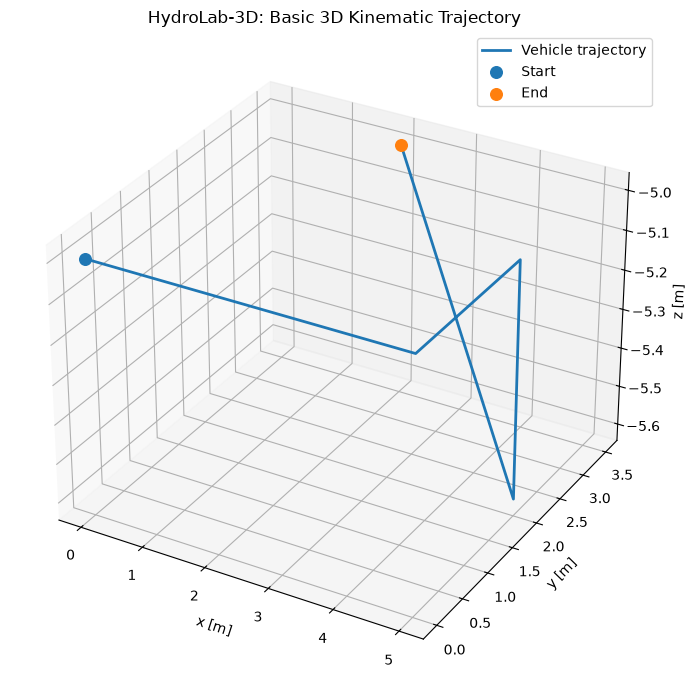

3D trajectory plot generated successfully.
Saved to: /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/plots/trajectory_3d.png
File size: 309624 bytes


In [11]:
# ---------------------------------------------------------------------
# Generate 3D trajectory plot
# ---------------------------------------------------------------------

trajectory_plot_path = PLOTS_DIR / "trajectory_3d.png"

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    piecewise_history[:, 0],
    piecewise_history[:, 1],
    piecewise_history[:, 2],
    linewidth=2,
    label="Vehicle trajectory"
)

ax.scatter(
    piecewise_history[0, 0],
    piecewise_history[0, 1],
    piecewise_history[0, 2],
    s=70,
    label="Start"
)

ax.scatter(
    piecewise_history[-1, 0],
    piecewise_history[-1, 1],
    piecewise_history[-1, 2],
    s=70,
    label="End"
)

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")

ax.set_title("HydroLab-3D: Basic 3D Kinematic Trajectory")
ax.legend()

fig.tight_layout()

fig.savefig(
    trajectory_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------------------
# Verify saved artifact
# ---------------------------------------------------------------------

assert trajectory_plot_path.exists()
assert trajectory_plot_path.stat().st_size > 0


print("3D trajectory plot generated successfully.")
print(f"Saved to: {trajectory_plot_path.resolve()}")
print(f"File size: {trajectory_plot_path.stat().st_size} bytes")

## Step 12 - Generate the Position-vs-Time Plot

The 3D trajectory shows the spatial path of the vehicle, but it does not directly show when each coordinate changes.

We therefore generate a time-history plot of

$$
x(t), \qquad y(t), \qquad z(t)
$$

using the validated piecewise-command trajectory from Step 8.

For piecewise-constant velocity commands, each position coordinate should evolve piecewise linearly:

$$
p_i(t+\Delta t)
=
p_i(t)
+
v_i\Delta t.
$$

The expected behavior is:

- $x(t)$ increases during the first segment, remains constant during the next two segments, and decreases during the final segment;
- $y(t)$ remains constant initially, increases during the second segment, remains constant during the third, and increases again during the final segment;
- $z(t)$ remains constant during the first two segments, decreases during the third segment, and rises back toward its original depth during the final segment.

The resulting figure will be stored at:

    results/notebooks/00_basic_3d_kinematics/plots/position_vs_time.png

This provides a complementary validation view of the same trajectory by exposing the temporal evolution of each world-frame coordinate.

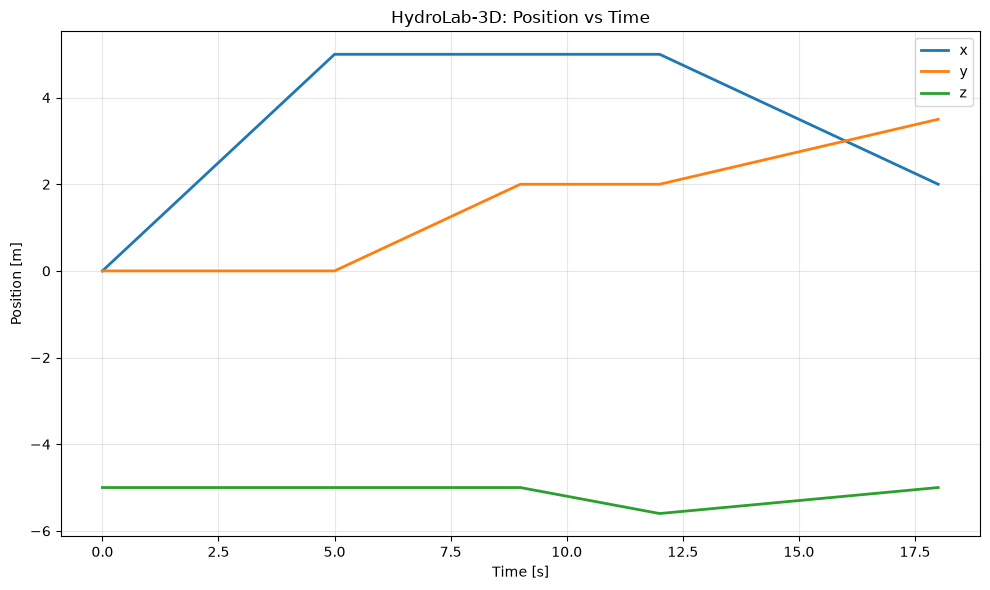

Position-vs-time plot generated successfully.
Saved to: /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/plots/position_vs_time.png
File size: 84318 bytes


In [12]:
# ---------------------------------------------------------------------
# Generate position-vs-time plot
# ---------------------------------------------------------------------

position_time_plot_path = PLOTS_DIR / "position_vs_time.png"

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    piecewise_time,
    piecewise_history[:, 0],
    linewidth=2,
    label="x"
)

ax.plot(
    piecewise_time,
    piecewise_history[:, 1],
    linewidth=2,
    label="y"
)

ax.plot(
    piecewise_time,
    piecewise_history[:, 2],
    linewidth=2,
    label="z"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position [m]")

ax.set_title("HydroLab-3D: Position vs Time")
ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

fig.savefig(
    position_time_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------------------
# Verify saved artifact
# ---------------------------------------------------------------------

assert position_time_plot_path.exists()
assert position_time_plot_path.stat().st_size > 0


print("Position-vs-time plot generated successfully.")
print(f"Saved to: {position_time_plot_path.resolve()}")
print(f"File size: {position_time_plot_path.stat().st_size} bytes")

## Step 13 - Save the Validated Trajectory Dataset

The visual artifacts confirm that the piecewise-command trajectory behaves correctly, but later notebooks may also need the underlying numerical state history.

We therefore save the validated trajectory from Step 8 as a CSV file.

Each row corresponds to one recorded simulation state and contains:

- simulation time;
- world-frame position $(x,y,z)$;
- commanded world-frame velocity $(v_x,v_y,v_z)$.

The dataset will use the column order

    time, x, y, z, vx, vy, vz

and will be stored at

    results/notebooks/00_basic_3d_kinematics/data/trajectory.csv

The initial row at $t=0$ represents the initial state before any command has been applied, so its recorded command velocity is

$$
\mathbf{v}_0=
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}.
$$

Subsequent rows record the velocity command responsible for the state transition that produced that row.

This file provides a persistent numerical artifact that can be inspected independently of the notebook and referenced during later HydroLab-3D development.

In [13]:
# ---------------------------------------------------------------------
# Assemble trajectory dataset
# ---------------------------------------------------------------------

trajectory_csv_path = DATA_DIR / "trajectory.csv"

trajectory_data = np.column_stack(
    (
        piecewise_time,
        piecewise_history,
        piecewise_velocity_history
    )
)

trajectory_header = "time,x,y,z,vx,vy,vz"


# ---------------------------------------------------------------------
# Save CSV
# ---------------------------------------------------------------------

np.savetxt(
    trajectory_csv_path,
    trajectory_data,
    delimiter=",",
    header=trajectory_header,
    comments="",
    fmt="%.10f"
)


# ---------------------------------------------------------------------
# Reload and validate persistent artifact
# ---------------------------------------------------------------------

loaded_trajectory = np.loadtxt(
    trajectory_csv_path,
    delimiter=",",
    skiprows=1
)

assert trajectory_csv_path.exists()
assert trajectory_csv_path.stat().st_size > 0

assert loaded_trajectory.shape == (expected_total_steps + 1, 7)

assert np.all(np.isfinite(loaded_trajectory))

assert np.allclose(
    loaded_trajectory[:, 0],
    piecewise_time,
    atol=1e-10,
    rtol=0.0
)

assert np.allclose(
    loaded_trajectory[:, 1:4],
    piecewise_history,
    atol=1e-10,
    rtol=0.0
)

assert np.allclose(
    loaded_trajectory[:, 4:7],
    piecewise_velocity_history,
    atol=1e-10,
    rtol=0.0
)


print("Trajectory dataset saved and reloaded successfully.")
print(f"Saved to: {trajectory_csv_path.resolve()}")
print(f"Rows    : {loaded_trajectory.shape[0]}")
print(f"Columns : {loaded_trajectory.shape[1]}")
print(f"File size: {trajectory_csv_path.stat().st_size} bytes")
print()
print("First row:")
print(loaded_trajectory[0])
print()
print("Final row:")
print(loaded_trajectory[-1])

Trajectory dataset saved and reloaded successfully.
Saved to: /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/data/trajectory.csv
Rows    : 181
Columns : 7
File size: 16843 bytes

First row:
[ 0.  0.  0. -5.  0.  0.  0.]

Final row:
[18.    2.    3.5  -5.   -0.5   0.25  0.1 ]


## Step 14 - Verify All Notebook Outputs

Before closing Notebook 00, we perform a final artifact-level validation.

The notebook is expected to leave behind three persistent outputs:

    results/notebooks/00_basic_3d_kinematics/
    ├── plots/
    │   ├── trajectory_3d.png
    │   └── position_vs_time.png
    │
    └── data/
        └── trajectory.csv

This step verifies that:

- every required output file exists;
- every output file is non-empty;
- the saved trajectory dataset can still be loaded successfully;
- the CSV contains the expected 181 recorded states and 7 columns;
- the final saved position remains consistent with the analytically validated piecewise trajectory.

This is the final executable validation step in Notebook 00.

If all checks pass, the notebook has produced a complete and internally consistent set of artifacts and is ready for its concluding engineering handoff.

In [14]:
# ---------------------------------------------------------------------
# Final notebook artifact verification
# ---------------------------------------------------------------------

expected_artifacts = {
    "3D trajectory plot": trajectory_plot_path,
    "Position-vs-time plot": position_time_plot_path,
    "Trajectory dataset": trajectory_csv_path,
}

for artifact_name, artifact_path in expected_artifacts.items():
    assert artifact_path.exists(), f"Missing artifact: {artifact_path}"
    assert artifact_path.is_file(), f"Not a file: {artifact_path}"
    assert artifact_path.stat().st_size > 0, f"Empty artifact: {artifact_path}"


# ---------------------------------------------------------------------
# Revalidate persisted trajectory data
# ---------------------------------------------------------------------

final_trajectory_data = np.loadtxt(
    trajectory_csv_path,
    delimiter=",",
    skiprows=1
)

assert final_trajectory_data.shape == (181, 7)
assert np.all(np.isfinite(final_trajectory_data))

assert np.allclose(
    final_trajectory_data[-1, 1:4],
    expected_piecewise_final,
    atol=1e-10,
    rtol=0.0
)


# ---------------------------------------------------------------------
# Report final artifact status
# ---------------------------------------------------------------------

print("Final Notebook 00 artifact verification passed.")
print()

for artifact_name, artifact_path in expected_artifacts.items():
    print(f"{artifact_name}:")
    print(f"  Path      : {artifact_path.resolve()}")
    print(f"  Size      : {artifact_path.stat().st_size} bytes")
    print(f"  Exists    : {artifact_path.exists()}")
    print()

print(f"Trajectory rows    : {final_trajectory_data.shape[0]}")
print(f"Trajectory columns : {final_trajectory_data.shape[1]}")
print(f"Final position [m] : {final_trajectory_data[-1, 1:4]}")
print()
print("Notebook 00 executable validation is complete.")

Final Notebook 00 artifact verification passed.

3D trajectory plot:
  Path      : /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/plots/trajectory_3d.png
  Size      : 309624 bytes
  Exists    : True

Position-vs-time plot:
  Path      : /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/plots/position_vs_time.png
  Size      : 84318 bytes
  Exists    : True

Trajectory dataset:
  Path      : /home/agniacolyte/HydroLab-3D/results/notebooks/00_basic_3d_kinematics/data/trajectory.csv
  Size      : 16843 bytes
  Exists    : True

Trajectory rows    : 181
Trajectory columns : 7
Final position [m] : [ 2.   3.5 -5. ]

Notebook 00 executable validation is complete.


# Conclusion

## What Was Implemented

Notebook 00 established the first validated motion model for HydroLab-3D: a deterministic three-dimensional world-frame kinematic vehicle model.

The implemented model propagates position according to

$$
\dot{\mathbf{p}}=\mathbf{v},
$$

with discrete-time propagation

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t.
$$

The notebook implemented:

- three-dimensional position representation;
- three-dimensional world-frame velocity representation;
- timestep-based position propagation;
- reusable one-step position integration;
- deterministic constant-velocity simulation;
- piecewise-constant velocity commands;
- trajectory generation;
- analytical reference solutions;
- numerical-error evaluation;
- reproducibility validation;
- persistent trajectory logging;
- three-dimensional trajectory visualization;
- position-versus-time visualization.

The vehicle in this notebook remains a purely kinematic point model.

No orientation, forces, acceleration, hydrodynamics, or actuator behavior are modeled yet.

---

## What Was Validated

The kinematic implementation was tested progressively from the simplest invariant case to a full three-dimensional trajectory.

### Stationary Vehicle

A vehicle initialized at

$$
\mathbf{p}_0=
\begin{bmatrix}
4 \\
-3 \\
-12
\end{bmatrix}
$$

with zero velocity remained exactly stationary for 100 simulation steps over 10 seconds.

Maximum observed drift:

$$
0.0\text{ m}.
$$

### Pure X-Axis Motion

Independent positive $x$ motion was validated against the analytical solution over 10 seconds.

Maximum observed error:

$$
2.665\times10^{-14}\text{ m}.
$$

The $y$ and $z$ coordinates remained unchanged.

### Pure Y-Axis Motion

Independent $y$ motion was validated with maximum error

$$
6.217\times10^{-15}\text{ m}.
$$

The uncommanded $x$ and $z$ coordinates remained unchanged.

### Pure Z-Axis Motion

Independent underwater depth motion was validated with maximum error

$$
4.086\times10^{-14}\text{ m}.
$$

The uncommanded $x$ and $y$ coordinates remained unchanged.

### Simultaneous 3D Motion

Constant velocity

$$
\mathbf{v}
=
\begin{bmatrix}
1.2 \\
-0.7 \\
0.3
\end{bmatrix}
\text{ m/s}
$$

was propagated for 20 seconds.

The numerical final position matched the analytical result:

$$
\mathbf{p}(20)=
\begin{bmatrix}
25 \\
-16 \\
1
\end{bmatrix}
\text{ m}.
$$

Maximum trajectory error:

$$
4.619\times10^{-14}\text{ m}.
$$

### Piecewise-Constant Commands

A four-segment velocity sequence was executed successfully.

The trajectory followed

    (0, 0, -5)
        ↓
    (5, 0, -5)
        ↓
    (5, 2, -5)
        ↓
    (5, 2, -5.6)
        ↓
    (2, 3.5, -5)

The final numerical position was

$$
\mathbf{p}_{final}
=
\begin{bmatrix}
2 \\
3.5 \\
-5
\end{bmatrix}
\text{ m},
$$

matching the analytically accumulated displacement.

Final absolute coordinate error:

$$
\begin{bmatrix}
8.882\times10^{-15} \\
4.441\times10^{-15} \\
0
\end{bmatrix}
\text{ m}.
$$

### Numerical Error

A dedicated 400-step analytical comparison over 20 seconds produced:

- maximum coordinate error:

$$
1.936\times10^{-13}\text{ m};
$$

- mean coordinate error:

$$
4.549\times10^{-14}\text{ m};
$$

- maximum Euclidean position error:

$$
2.014\times10^{-13}\text{ m}.
$$

All errors remained far below the notebook validation threshold of

$$
10^{-10}\text{ m}.
$$

Because velocity is constant within each integration interval, the update used here is exact for the underlying constant-velocity model. The remaining error is therefore attributable to finite-precision floating-point arithmetic rather than integration truncation.

### Reproducibility

Two independent executions of the same deterministic scenario produced identical trajectories.

Maximum difference between repeated runs:

$$
0.000\times10^{0}\text{ m}.
$$

All timestamps and state values remained finite, and simulation time increased monotonically.

---

## Key Results

Notebook 00 successfully demonstrated that HydroLab-3D can propagate a three-dimensional translational state correctly and reproducibly.

The validated relationship is

$$
\boxed{
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
}
$$

for velocity that remains constant within each simulation interval.

The complete validation suite produced errors on the order of approximately

$$
10^{-13}
\text{ to }
10^{-15}\text{ m},
$$

which is substantially below the required tolerance.

The core 3D kinematic layer can therefore be treated as validated for the scope of this notebook.

---

## Generated Outputs

Notebook 00 generated the following persistent artifacts:

### Plots

- `trajectory_3d.png`
- `position_vs_time.png`

### Numerical Data

- `trajectory.csv`

The trajectory dataset contains:

    time
    x
    y
    z
    vx
    vy
    vz

with:

- 181 recorded states;
- 7 columns;
- simulation duration of 18 seconds.

The final saved state is

$$
\mathbf{p}_{final}
=
\begin{bmatrix}
2 \\
3.5 \\
-5
\end{bmatrix}
\text{ m}.
$$

---

## Output Location

All persistent outputs from this notebook are stored in:

    results/notebooks/00_basic_3d_kinematics/

with the structure

    results/notebooks/00_basic_3d_kinematics/
    │
    ├── plots/
    │   ├── trajectory_3d.png
    │   └── position_vs_time.png
    │
    └── data/
        └── trajectory.csv

These paths should be used when later notebooks or validation work need to reference Notebook 00 artifacts.

---

## Important Observations

The discrete kinematic update used in this notebook is particularly simple because velocity is prescribed directly.

For each simulation interval,

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k+\mathbf{v}_k\Delta t.
$$

When $\mathbf{v}_k$ remains constant throughout that interval, this expression is the exact propagation of the continuous constant-velocity model.

This means Notebook 00 does not yet expose the numerical integration challenges that will appear when acceleration becomes state-dependent or when nonlinear vehicle dynamics are introduced.

The small numerical errors observed here are caused by finite floating-point representation and repeated arithmetic operations.

The piecewise-command experiment also demonstrates that a trajectory can already be constructed from sequential commands without introducing any dynamics.

This provides a minimal but trustworthy state-propagation foundation for HydroLab-3D.

---

## Current Limitations

Notebook 00 intentionally does not model:

- roll;
- pitch;
- yaw;
- orientation;
- body-frame coordinates;
- reference-frame transformations;
- acceleration;
- mass;
- forces;
- torques;
- vehicle inertia;
- hydrodynamic drag;
- gravity;
- buoyancy;
- thrusters;
- ocean currents;
- terrain interaction;
- sensors;
- control systems;
- communication;
- rendering;
- ROS 2;
- learning-based methods.

Velocity is commanded directly in the world frame.

Therefore,

$$
\mathbf{v}_{command}
=
\mathbf{v}_{world}.
$$

This is intentionally temporary.

A real underwater vehicle normally generates motion relative to its own orientation and body frame.

---

## How This Result Will Be Used

The validated position integration logic forms the first mathematical layer of the HydroLab-3D vehicle model.

Conceptually:

    World-frame velocity
            ↓
    Position integrator
            ↓
       Updated position

The validated relationship

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k+\mathbf{v}_k\Delta t
$$

will remain useful as later notebooks introduce additional layers above it.

The immediate next development stage will determine the world-frame velocity from a body-frame velocity and vehicle orientation.

Conceptually:

    Body-frame velocity
            ↓
       Orientation
            ↓
    Rotation transformation
            ↓
    World-frame velocity
            ↓
    Validated position integration
            ↓
       Updated position

The reusable kinematic implementation may later be promoted into:

    src/hydrolab3d/dynamics/kinematics.py

once the notebook-to-source transition is performed.

Notebook 00 therefore establishes both a mathematical reference and a regression baseline for future HydroLab-3D implementations.

---

## Next Notebook

The next development stage is:

# Notebook 01 - Orientation and Reference Frames

Notebook 01 will introduce:

- roll;
- pitch;
- yaw;
- vehicle attitude;
- body-frame velocity;
- world-frame velocity;
- rotation matrices;
- coordinate transformations.

The key relationship will become

$$
\mathbf{v}_{world}
=
R(\phi,\theta,\psi)
\mathbf{v}_{body}.
$$

The position propagation validated in Notebook 00 can then remain unchanged:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_{world,k}\Delta t.
$$

The engineering handoff is therefore:

    Notebook 00
        │
        │ validated world-frame position integration
        ▼
    Notebook 01
        │
        │ orientation and reference-frame transformation
        ▼
    Body-relative 3D vehicle motion

Notebook 00 establishes **where a commanded world-frame velocity moves the vehicle**.

Notebook 01 will establish **how vehicle orientation converts body-relative motion into that world-frame velocity**.

---